<a href="https://colab.research.google.com/github/CeZa18/ITAI-1371-ML-Labs/blob/main/FP_MentalHelathSentimentAnalysis_CesarZaldivar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**


While there are clear operational and strategic reasons for this analysis, selecting this dataset carries significant real-world weight. Mental health platforms and telehealth providers require scalable NLP tools to triage user-generated content efficiently. This project builds a machine learning pipeline to classify social media posts into mental health sentiment categories, helping streamline the routing of users toward appropriate support resources.

**The central research question is**: Can a machine learning classifier, trained on TF-IDF features, accurately distinguish between *Stable*, *Moderate*, and *Severe* mental health sentiment from raw social media text?

_**Disclaimer:** This project is strictly educational. The classifier is not intended for clinical diagnosis and should never substitute for licensed mental health evaluation. All data consists of anonymized, publicly available social media posts._

---

**Dataset Description:**

The dataset consists of 53K records with a 13.6:1 ratio. The model is adjusted to ~15K records for speed and performance, and to address the new dataset imbalance 2.6:1 (Stable:Moderate - Severe dominates at 56.3%) and align with clinical severity tiers, the dataset's 7 original sentiment labels are consolidated into 3 target classes.

- **Target Classes**:
  - `Stable` (Normal)
  - `Moderate` (Anxiety, Stress)
  - `Severe` (Depression, Suicidal, Bipolar, Personality Disorder)
- **Dataset name**: `Combined_Data.csv`
- **Source**: Kaggle (suchintikasarkar)
- **Number of samples**: 53,043 rows
- **Columns**:
  - `unique_id` (ID)
  - `statement` (raw text)
  - `status` (mental health label)
- **Text field**: `statement` — free-form, unformatted  social media posts containing noisy text
- **Original Sentiment labels (7)**: Normal, Depression, Suicidal, Anxiety, Stress, Bipolar, Personality Disorder

---

**Importance and Real-World Applications:**

In recent years, societal focus on mental health—its diagnosis, public triggers (e.g. News Media), and treatment—has grown exponentially. As the digital health tools transition into the AI era, numerous studies demonstrate that incorporating ML models improves early detection and allows for prompt triage:

 > _"sentiment analysis, emotion detection, and event extraction can be used to assess media responses to societal events, such as economic crises or health emergencies, and can reveal patterns of anxiety, depression, and well-being at the population level."_ <a href="#ref1">[1]</a> <a href="#ref2">[2]</a> <a href="#ref3">[3]</a>

Research indicates a strong correlation between Media consumption and population-level mental health, and that the implementation of AI-driven sentiment analysis greatly enhances physicians' capacity to track and address patients' emotions, resulting in more individualized treatment regimens and higher patient engagement. <a href="#ref4">[4]</a>


***

### References

<a href="#ref1">[1]</a>: Köckritz, J., İlgen, B., Cohrdes, C. et al. Current applications and future directions in natural language processing for news media and mental health. Sci Rep 15, 32532 (2025). https://doi.org/10.1038/s41598-025-18413-z

<a href="#ref2">[2]</a>: Galea, S., Merchant, R. M. & Lurie, N. The mental health consequences of covid-19 and physical distancing: The need for prevention and early intervention. JAMA Intern. Med. 180(6), 817. https://doi.org/10.1001/jamainternmed.2020.1562 (2020) (ISSN 2168-6106).

<a href="#ref3">[3]</a>: Purtle, J., Nelson, K. L., Counts, N. Z. & Yudell. M. Population-based approaches to mental health: History, strategies, and evidence. Annu. Rev. Public Health 41(1), 201–221 (2020).

<a href="#ref4">[4]</a>: Hsu, C., Ismail, S. M., Ahmad, I., Abdelrasheed, N. S. G., Ballal, S., Kalia, R., Sabarivani, A., Sahoo, S., Prasad, K., & Khosravi, M. (2025). The impact of AI-driven sentiment analysis on patient outcomes in psychiatric care: A narrative review. Asian Journal of Psychiatry, 107, 104443. https://doi.org/10.1016/j.ajp.2025.104443


---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
#plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)

# YOUR CODE HERE
import pandas as pd
import os
from google.colab import userdata


# Retrive API keys from Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Kagglehub will use the keys to authenticate
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

# See what files downloaded
print("Files found:", os.listdir(path))

# Load the CSV avoiding the unnecessary columns with no analytical value (ID column) and limiting it 15000 rows to improve performance
df = pd.read_csv(os.path.join(path, 'Combined Data.csv'), index_col=0)

# Rename columns for clarity
df.rename(columns={'statement': 'text', 'status': 'sentiment'}, inplace=True)

# Preserve random sample to maintain distribution integrity of the dataset
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

# Display basic information
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n")
df.head()

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Files found: ['Combined Data.csv']
✅ Loaded: 15,000 rows × 2 columns

Column names: ['text', 'sentiment']

Data types:
text         object
sentiment    object
dtype: object

First 5 rows:



,text,sentiment
0,"Just as the the title says. I feel like one is hyper alot, a attention whore, and is idealistic ...",Depression
1,a blackened sky encroached tugging behind it my depression,Depression
2,"It gives you insomnia, which in turn makes your depression worse during the day, which messes up...",Depression
3,"Hello all, I'm a new submitter to this channel. I went here a few nights ago and honestly it's b...",Normal
4,Thank God the CB is over for Eid,Normal


In [3]:
# Check for missing values
# YOUR CODE HERE

# Hint: Use df.isnull().sum() or df.info()

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)

# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print(f"\n{'='*50}")
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Drop duplicates and nulls if any
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f"\n{'+'*50}")
print(f"\nClean dataset shape: {df.shape}")

MISSING VALUES
text         122
sentiment      0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 283

++++++++++++++++++++++++++++++++++++++++++++++++++

Clean dataset shape: (14712, 2)


In [4]:
# Save original 7-Class counts before overwriting
original_counts =df['sentiment'].value_counts()


# Create 3-class collapsed column
def collapse_labels(label):
  if label == 'Normal':
    return 'Stable'
  elif label in ['Anxiety', 'Stress']:
    return 'Moderate'
  else: # Depression, Suicidal, Bipolar, Personality Disorder
    return 'Severe'

# Create collapsed column
df['sentiment'] = df['sentiment'].apply(collapse_labels)

print("✅ Sentiment labels collapsed to 3 classes (Stable, Moderate, Severe).")
print("\nNew sentiment distribution:")
print(df['sentiment'].value_counts())

✅ Sentiment labels collapsed to 3 classes (Stable, Moderate, Severe).

New sentiment distribution:
sentiment
Severe      8288
Stable      4631
Moderate    1793
Name: count, dtype: int64


In [5]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:


# No need to reduce sample set to 5000 samples since the samples have already been reduced to 14,712 enough to run lean
print(f"Working with {len(df):,} samples")
# Use the sample for the rest of the project


Working with 14,712 samples


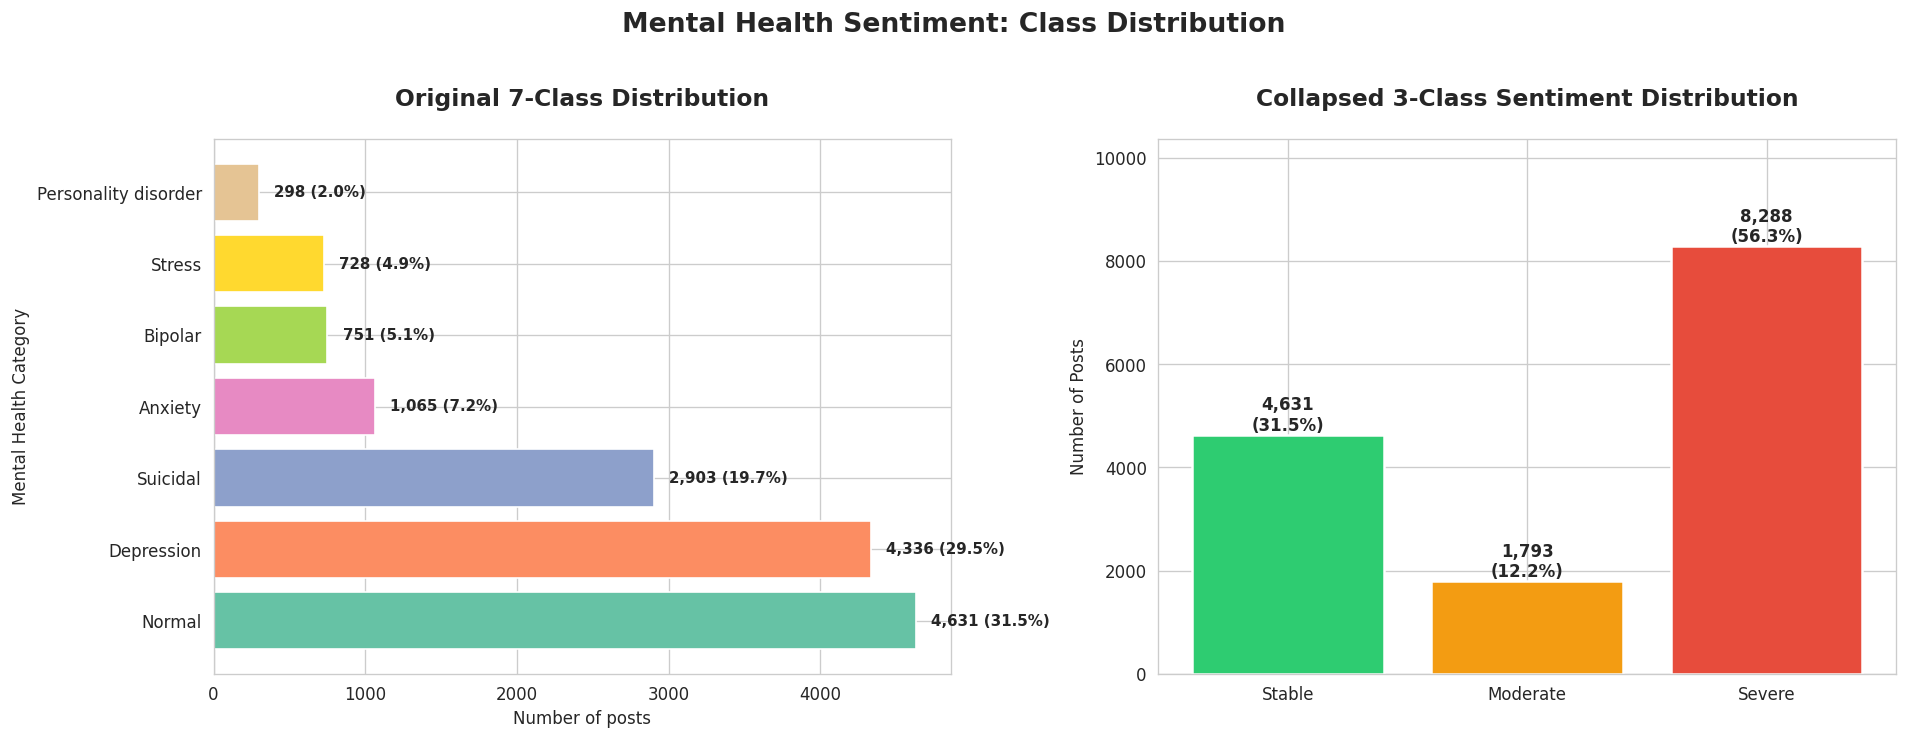


Imbalance ratio (Stable:Moderate): 2.6:1


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze sentiment distribution
# YOUR CODE HERE

# Hint: Use df['sentiment_column'].value_counts()
# Create a bar plot to visualize the distribution
fig, axes = plt. subplots(1, 2, figsize=(16, 6))

# Left: Original 7-class
#original_counts = df['sentiment'].value_counts()
colors_7 = sns.color_palette("Set2", len(original_counts))
axes[0].barh(original_counts.index, original_counts.values, color=colors_7)
axes[0].set_title('Original 7-Class Distribution', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Number of posts')
axes[0].set_ylabel('Mental Health Category')
for i, v in enumerate(original_counts.values):
    axes[0].text(v + 100, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9, fontweight='bold')

# Right: Collapsed 3-class
sent_counts = df['sentiment'].value_counts().reindex(['Stable', 'Moderate', 'Severe'])
colors_3 = ['#2ecc71', '#f39c12', '#e74c3c'] # Green / Orange / Red

bars = axes[1].bar(sent_counts.index, sent_counts.values,
                   color=colors_3, edgecolor='white', linewidth=1.5)
axes[1].set_title('Collapsed 3-Class Sentiment Distribution', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Number of Posts')
axes[1].set_ylim(0, sent_counts.max() * 1.25)
for i, (label, count) in enumerate(sent_counts.items()):
    axes[1].text(i, count + 80, f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Mental Health Sentiment: Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(f"\nImbalance ratio (Stable:Moderate): {sent_counts['Stable']/sent_counts['Moderate']:.1f}:1")


### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?
- If imbalanced, how might this affect your model?
- What could you do to address imbalance?

***


The original dataset contains 7 unequal classes reflecting diverse mental health conditions. To create a more tractable classification task, the classes were collapsed into three clinically-informed tiers: **Stable** (Normal posts, 31.5%), **Moderate** (Anxiety + Stress, 12.2%), and **Severe** (Depression, Bipolar, Suicidal Ideation, Personality Disorder, 56.3%). This collapse preserves meaningful clinical distinction while reducing lable sparcity. The resulting 4.6:1 Sever-to-Moderate imbalance is directly addressed through `class_weight+'balanced'` during model trining and by prioritizing macro F1-score — which weights three classes equally — over raw accuracy during evaluation.

Text Length Statistics by Sentiment Class:
          text_length                    word_count                 
                 mean min    max     std       mean min   max    std
sentiment                                                           
Moderate        714.1  11   8539   730.1      133.6   2  1592  135.6
Severe          822.8   6  32759  1014.6      162.5   1  6300  198.5
Stable           87.9   3   1018   116.2       16.8   1   191   21.9


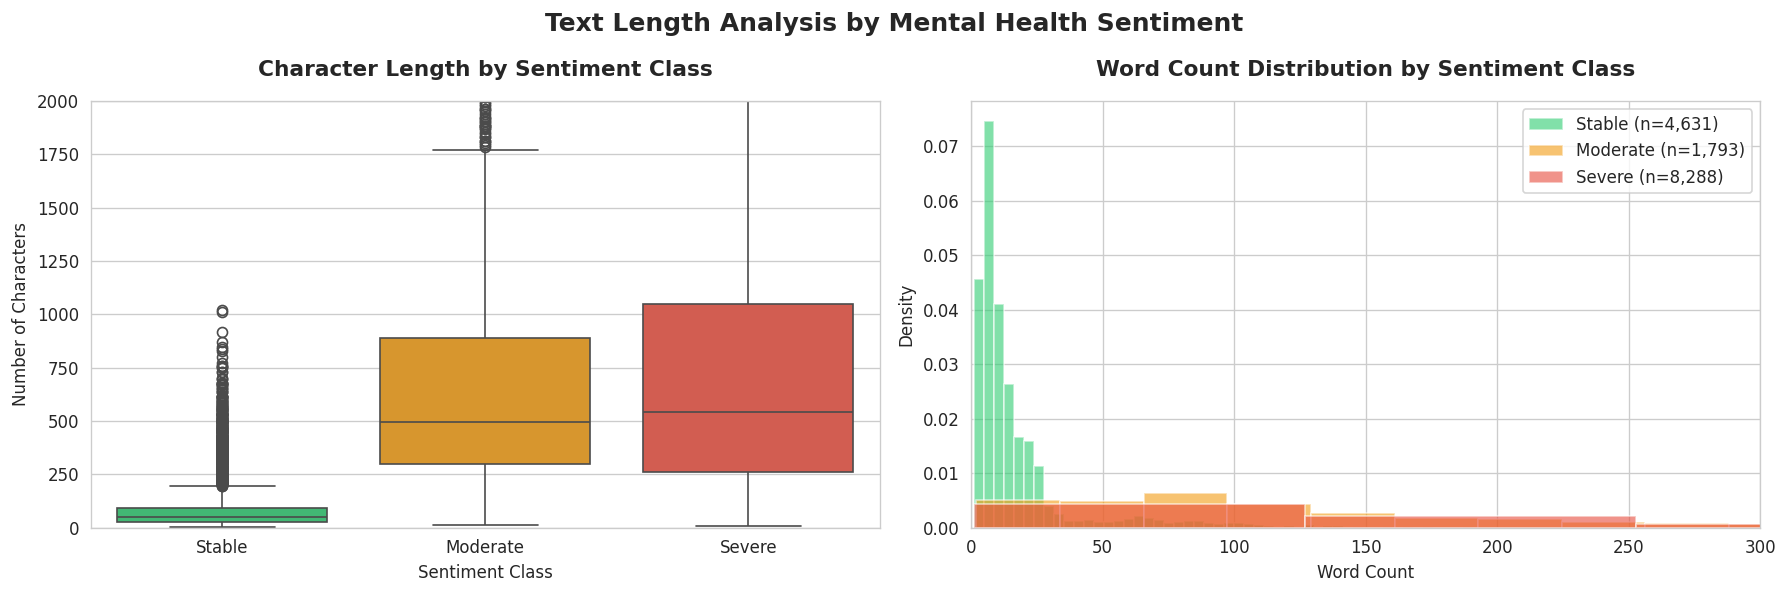

Stable     - avg words: 17  | medium chars: 48  | max words: 191
Moderate   - avg words: 134  | medium chars: 494  | max words: 1592
Severe     - avg words: 163  | medium chars: 540  | max words: 6300


In [7]:
from sklearn.utils.extmath import density
# Analyze text length distribution
# YOUR CODE HERE

# Hint: Create a new column for text length
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

# Plot histogram of text lengths
# Compare lengths across different sentiments

# Summary statistics by class
print("Text Length Statistics by Sentiment Class:")
print(df.groupby('sentiment')[['text_length', 'word_count']]
      .agg(['mean', 'min', 'max', 'std']).round(1).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = ['Stable', 'Moderate', 'Severe']
pallette = {'Stable': '#2ecc71', 'Moderate': '#f39c12', 'Severe': '#e74c3c'}

# Left — box plot: character length per class
sns.boxplot(data=df, x='sentiment', y='text_length',
            order=order, palette=pallette, ax=axes[0])
axes[0].set_title('Character Length by Sentiment Class',
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Characters')
axes[0].set_ylim(0, 2000)

# Right — overlapping density histograms: word count per class
for sentiment, color in pallette.items():
    subset = df[df['sentiment'] == sentiment]['word_count']
    axes[1].hist(subset, bins=50, alpha=0.6,
                 label=f'{sentiment} (n={len(subset):,})',
                 color=color, density=True)
axes[1].set_title('Word Count Distribution by Sentiment Class',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 300)
axes[1].legend()

plt.suptitle('Text Length Analysis by Mental Health Sentiment',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('text_length_distribution.png')
plt.show()

# Summary Printout
for s in order:
  subset = df[df['sentiment'] == s]
  print(f"{s:10s} - avg words: {subset['word_count'].mean():.0f}  "
        f"| medium chars: {subset['text_length'].median():.0f}  "
        f"| max words: {subset['word_count'].max()}")


### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?
- Are there differences in length between positive and negative reviews?
- Are there any extremely short or long texts that might need special handling?

***


Text length reveals a stricking structural difference across classes. Stable posts average only **17 words** (median 48 characters), while Moderate and Severe posts average **134** and **163 words** repectively — nearly a 10x difference. This pattern is clinically consistent: individuals experiencing depression or crisis tend to produce longer, more ruminative text, while stable everyday posts are brief and conversational. Sever posts also carry the widest variance, including outliers exceeding 6,000 words — lengthy forum posts or personal narratives. This structural signal suggests that the text length could serve as a useful engineered feature alongside TF-IDF in the future iterations of this model.

In [8]:
# Display sample reviews from each sentiment class
# YOUR CODE HERE

# Hint: Use df[df['sentiment'] == 'positive'].sample(3)
# Display examples from each class to get a feel for the data

print("=" * 80)
print("SAMPLE POSTS BY SENTIMENT CLASS")
print("=" * 80)

for sentiment in ['Stable', 'Moderate', 'Severe']:
  print(f"\n{'-'*80}")
  print(f"  CLASS:  {sentiment.upper()}")
  print(f"{'-'*80}")
  samples = df[df['sentiment'] == sentiment]['text'].sample(2, random_state=42)
  for j, text in enumerate(samples, 1):
    print(f"\n  [{j}] {text[:400]}{'...' if len(text) > 400 else ''}")

print(f"\n{'='*80}")


SAMPLE POSTS BY SENTIMENT CLASS

--------------------------------------------------------------------------------
  CLASS:  STABLE
--------------------------------------------------------------------------------

  [1] This was literally the first meal I've had with other people in nearly a year. This couple was young enough to be my children and I could picture myself in their situation which I pray will never happen, but if it does I would really hope someone would buy me some food every once in a while. The guy seemed a bit sheepish, but the woman seemed a bit more comfortable with being homeless. They seemed...

  [2] damn I had a dream that I had a cute cute cat named PojiðŸ˜

--------------------------------------------------------------------------------
  CLASS:  MODERATE
--------------------------------------------------------------------------------

  [1] Intrusive thoughts I feel like my intrusive thoughts are winning right now, and I feel bad for every thought. I feel like

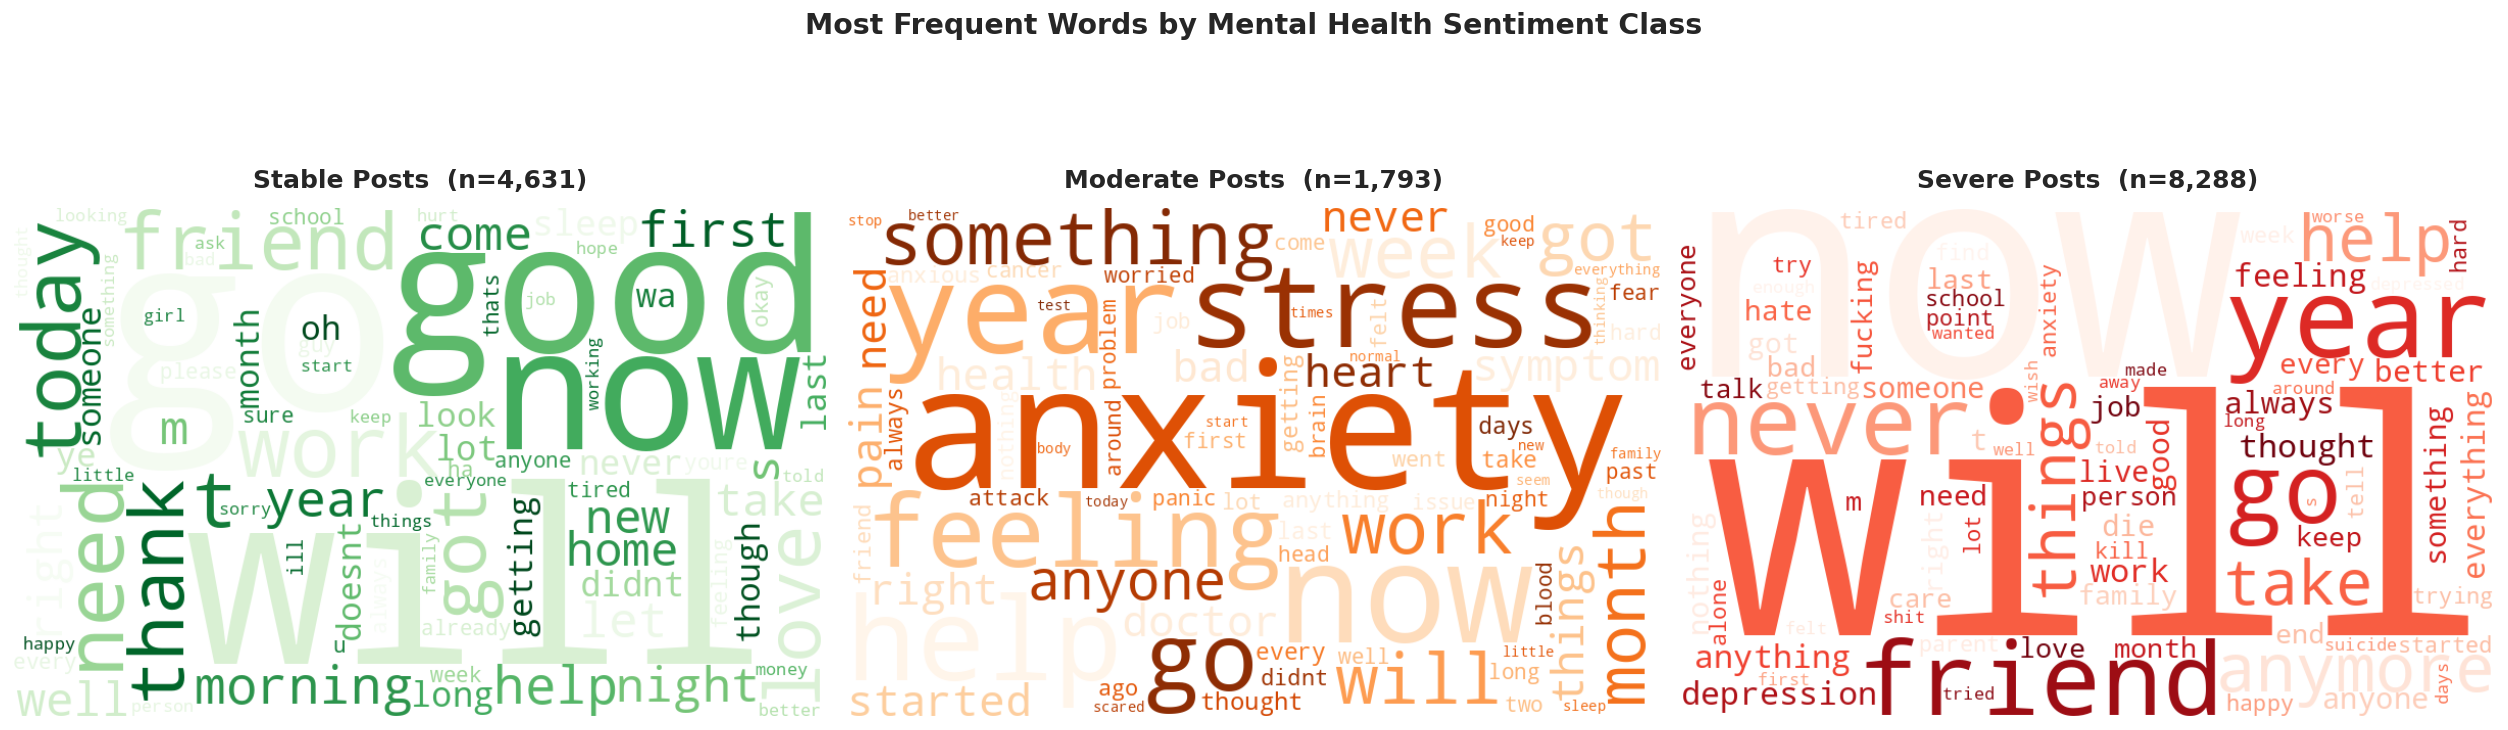

In [9]:
# Analyze common words (optional but recommended)
# YOUR CODE HERE

# Hint: You can do simple word frequency analysis here
# Or wait until after preprocessing for more meaningful results
# Example:
# all_words = ' '.join(df['text_column']).lower().split()
# common_words = Counter(all_words).most_common(20)
# Plot a bar chart of most common words

import re

def clean_for_cloud(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+', '', text)
  text = re.sub(r'@\w+|#\w', '', text)
  text = re.sub(r'[^\x00-\x7F]+', '', text)
  text = re.sub(r'[^\w\s]', '', text)
  return text

custom_stopwrods = set(STOPWORDS) | {
    'feel', 'like', 'just', 'know', 'want', 'really', 'get', 'one',
    'thing', 'time', 'would', 'could', 'im', 'ive', 'dont', 'cant',
    'even', 'still', 'much', 'make', 'going', 'people', 'think',
    'life', 'way', 'day', 'back', 'see', 'also', 'said', 'say'
}

cmap = {'Stable': 'Greens', 'Moderate': 'Oranges', 'Severe': 'Reds'}
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, sentiment in zip(axes, ['Stable', 'Moderate', 'Severe']):
  subset = df[df['sentiment'] == sentiment]['text']
  text_data = ' '.join(
      subset.sample(min(3000, len(subset)), random_state=42)
      .apply(clean_for_cloud)
  )
  wc = WordCloud(
      width=800, height=500,
      background_color='white',
      colormap=cmap[sentiment],
      stopwords=custom_stopwrods,
      max_words=80,
      collocations=False
  ).generate(text_data)
  ax.imshow(wc, interpolation='bilinear')
  ax.axis('off')
  ax.set_title(f'{sentiment} Posts  (n={len(subset):,})',
               fontsize=15, fontweight='bold', pad=12)

plt.suptitle('Most Frequent Words by Mental Health Sentiment Class',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()


### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**:
2. **Data quality issues**:
3. **Key patterns observed**:
4. **Potential challenges**:

**Dataset Summary:** 14,712 posts retained after removing 122 null values and 283 duplicates from a 15,000-row random sample. Two columns used: `text` (raw post) and `sentiment` (3-class target). Class distribution after collapse: Severe 56.3%, Stable 31.5%, Moderate 12.2%.

**Key patterns:** sever posts are ~10x longer than Stable posts on average; vocabulary differs sharply across classes as confirmed by word clouds; the 4.6:1 Sever-to-Moderate imbalance requires class-balanced training.

**Primarry challenge:** Moderate is the smallest class with the most ambiguos language, making it the hardest to classify correctly.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [10]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [11]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
    # YOUR CODE HERE

    # Hint: Steps to implement:
    # 1. Convert to lowercase:
    text = str(text).lower()
    # 2. Remove URLs:
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags:
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation:
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Remove numbers:
    text = re.sub(r'\d+', '', text)
    # 6. Remove extra whitespace:
    text = ' '.join(text.split())
    # 7. Remove stopwords (using sklearn's built-in list from previous cell)
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    # 8. Remove extra whitespace
    text = ' '.join(tokens)
    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: test check


In [12]:
# Apply preprocessing to your dataset
# YOUR CODE HERE

# Hint:
# df['cleaned_text'] = df['text_column'].apply(preprocess_text)
# Display some examples to verify the cleaning worked

# Apply preprocesing to dataset
print("Applaying preprocessing - this may take 30-60 seconds...")

df['cleaned_text'] = df['text'].apply(preprocess_text)

# Verify it worked - compare raw vs cleaned
print("✅ Text preprocessing complete!")
print(f"Rows processed: {len(df):,}")
print(f"\n—————————————— Sample comparison ————————————————————————————————————")
for i in range(3):
  print(f"\n  RAW     : {df['text'].iloc[i][:120]}")
  print(f"  CLEANED : {df['cleaned_text'].iloc[i][:120]}")


Applaying preprocessing - this may take 30-60 seconds...
✅ Text preprocessing complete!
Rows processed: 14,712

—————————————— Sample comparison ————————————————————————————————————

  RAW     : Just as the the title says. I feel like one is hyper alot, a attention whore, and is idealistic and stupid. and the othe
  CLEANED : just title says feel like hyper alot attention whore idealistic stupid calm trys normal realist wants kill witch somtime

  RAW     : a blackened sky encroached tugging behind it my depression
  CLEANED : blackened sky encroached tugging depression

  RAW     : It gives you insomnia, which in turn makes your depression worse during the day, which messes up your sleep even more, w
  CLEANED : gives insomnia turn makes depression worse day messes sleep gives anxiety just feels impossible function worse sleep sym


In [13]:
# Prepare your features (X) and target (y)
# YOUR CODE HERE

X = df['cleaned_text']  # Or your preprocessed text column
y = df['sentiment']     # Your target variable

# Check the shape
print(f"Features  : {X.shape[0]:,} documents")
print(f"Target    : {y.nunique()} classes → {y.unique().tolist()}")
print(f"\nClass distribution:")
print(y.value_counts())

Features  : 14,712 documents
Target    : 3 classes → ['Severe', 'Stable', 'Moderate']

Class distribution:
sentiment
Severe      8288
Stable      4631
Moderate    1793
Name: count, dtype: int64


In [14]:
# Split data into training and testing sets
# YOUR CODE HERE

# Hint:
X_train, X_test, y_train, y_test = train_test_split(
     X, y,
     test_size=0.2,      # 80% train, 20% test
     random_state=42,    # For reproducibility
     stratify=y          # Maintain class distribution
 )

# print(f"Training samples: {len(X_train)}")
# print(f"Testing samples: {len(X_test)}")

print(f"Training set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing set  : {len(X_test):,}samples ({len(X_test)/len(X)*100:.0f}%)")
print(y_train.value_counts())
print(f"\nClass distribution - Test:")
print(y_test.value_counts())

Training set : 11,769 samples (80%)
Testing set  : 2,943samples (20%)
sentiment
Severe      6630
Stable      3705
Moderate    1434
Name: count, dtype: int64

Class distribution - Test:
sentiment
Severe      1658
Stable       926
Moderate     359
Name: count, dtype: int64


In [15]:
# Create TF-IDF features
# YOUR CODE HERE

# Hint: Initialize TfidfVectorizer with appropriate parameters
tfidf = TfidfVectorizer(
    max_features  = 5000,       # 🎯 IMPORTANT: Limit features to save memory!
    min_df        = 2,          # Ignore terms that appear in fewer than 2 documents
    max_df        = 0.8,        # Ignore terms that appear in more than 80% of documents
    ngram_range   = (1, 2),     # Use unigrams and bigrams
    stop_words    = 'english',  # Remove English stopwords
    sublinear_tf  = True        # log-scale TF to dampen repetition
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)       # transform only - no fit

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")
print(f"\nSparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2%} of values are zero")

TF-IDF matrix shape (train): (11769, 5000)
TF-IDF matrix shape (test): (2943, 5000)
Number of features: 5000

Sparsity: 99.31% of values are zero


In [16]:
# Explore the TF-IDF features (optional)
# YOUR CODE HERE

# Hint: Look at the most important features
feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:20])

print("\nTop 20 TF-IDF features (by highest mean score across training set):\n")
mean_scores = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices = mean_scores.argsort()[::-1][:20]

for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:<25s} score: {mean_scores[idx]:.5f}")

print(f"\nTotal vocabulary size : {len(feature_names):,} features")
print(f"Includes bigrams?       : {any(' ' in f for f in feature_names)}")

Sample features: ['abandoned' 'abandonment' 'abdomen' 'abilify' 'ability' 'able'
 'able afford' 'able help' 'able just' 'able live' 'able make'
 'able sleep' 'able talk' 'abnormal' 'abroad' 'absolute' 'absolutely'
 'absolutely hate' 'abt' 'abuse']

Top 20 TF-IDF features (by highest mean score across training set):

   1. just                      score: 0.03285
   2. like                      score: 0.02929
   3. want                      score: 0.02782
   4. feel                      score: 0.02468
   5. know                      score: 0.02171
   6. life                      score: 0.01982
   7. really                    score: 0.01828
   8. time                      score: 0.01805
   9. people                    score: 0.01742
  10. going                     score: 0.01653
  11. think                     score: 0.01531
  12. day                       score: 0.01513
  13. depression                score: 0.01481
  14. help                      score: 0.01341
  15. feel like         

### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**: Eight sequential cleaning steps were applied to all 14,712 posts: lowercase conversion, URL removal, @mention and hashtag removal, emoji and non-ASCII character removal, punctuation removal, number removal, English stopword filtering using sklearn's built-in list, and whitespace normalization.
2. **TF-IDF parameters chosen**: The vectorizer was configured with `max_features=5000`, `ngram_range=(1,2)`, `min_df=2`, `max_df=0.85`, `stop_words='english'`, and `sublinear_tf=True`.
3. **Final feature count**: 5,000 features representing the most informative unigrams and bigrams across the training corpus, stored in a sparse matrix of shape (11,769 × 5,000).
4. **Rationale for choices**: Bigrams were included to capture multi-word clinical phrases like panic attack or feel hopeless that unigrams would split apart, `sublinear_tf=True` prevents repetitive posts from dominating the feature space, and `max_df=0.85` filters near-universal terms that carry no discriminative value — while `min_df=2` removes rare typos and one-off tokens.
***

### **Preprocessing Approach**

Text preporcessing applies eight sequential steps: (1) lowercase conversion, (2) URL removal, (3) @mention and hashtag removal, (4) emoji and non-ASCI removal, (5) punctuation removal, (6) number removal, (7) stopword filtering using sklearn's built-in English stopword list, and (8) whitespace normalization. These steps reduce nosie while preserving the clinical vocabulary that carries sentiment signal. Stopwords like _the, is, a_ are removed, but clinically meaningful words like _depressed, anxious, suicidal_ are retained. The function is applied to the full 14,712=row dataset beofre any train/test split to ensure consistent cleaning.

### Rationale

TF-IDF was configured with max_features=5000 to limit memory usage while retaining the most informative terms, ngram_range=(1,2) to capture clinically significant bigrams like panic attack or feel hopeless that unigrams would split apart, min_df=2 to discard rare typos, max_df=0.85 to filter near-universal terms, and sublinear_tf=True to log-scale term frequencies and prevent repetitive posts from dominating the feature space. Critically, the vectorizer was fit only on the training set and then used to transform the test set — this prevents data leakage where test set vocabulary could influence feature selection. The resulting matrix has shape (11,769 × 5,000) — sparse but rich in discriminative signal.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [17]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [18]:
# Train Logistic Regression model
# YOUR CODE HERE

# Hint:
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,              # Increase if model doesn't converge
    random_state=42,
    class_weight='balanced',
    n_jobs=-1                   # Use all CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:03


In [19]:
# Make predictions with Logistic Regression
# YOUR CODE HERE

y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")
print(f"Sample predictions: {y_pred_lr[:10]}")

Predictions shape: (2943,)
Sample predictions: ['Stable' 'Severe' 'Stable' 'Stable' 'Stable' 'Severe' 'Stable' 'Severe'
 'Severe' 'Severe']


## Model 2: Multinomial Naive Bayes

In [20]:
# Train Naive Bayes model
# YOUR CODE HERE

# Hint:
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [21]:
# Make predictions with Naive Bayes
# YOUR CODE HERE

y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")
print(f"Sample predictions: {y_pred_nb[:10]}")

Predictions shape: (2943,)
Sample predictions: ['Stable' 'Severe' 'Stable' 'Severe' 'Severe' 'Severe' 'Stable' 'Severe'
 'Severe' 'Severe']


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [22]:
  # Train your third model (optional)
  # YOUR CODE HERE

  # Model 3 — LinearSVC for better text classfication
print("Trainin LinearSVC...")
start_time = time.time()

lsvc_model = LinearSVC(
      max_iter=2000,              # Increase if model doesn't converge
      random_state=42,
      class_weight='balanced'
)

lsvc_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

y_pred_lsvc = lsvc_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lsvc.shape}")
print(f"Sample predictions: {y_pred_lsvc[:10]}")

# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

Trainin LinearSVC...
✅ Training complete in 0:00:00
Predictions shape: (2943,)
Sample predictions: ['Stable' 'Severe' 'Stable' 'Stable' 'Stable' 'Severe' 'Stable' 'Severe'
 'Severe' 'Severe']


### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | 0:00:03 | 2,943 | |
| Naive Bayes | 0:00:00 | 2,943 | |
| (Optional) Model 3 | 0:00:00 | 2,943 | |


***

#### Model 1 — Logistic Regression rationale:

- Logistic Regression was selected as the primary model for its proven effectiveness on high-dimensional sparse TF-IDF feature spaces and its strong interpretability — the model's coefficients directly map to the most predictive words per class. `class_weight='balanced'` was applied to automatically compensate for the 4.6:1 class imbalance by increasing the penalty for misclassifying minority class samples. `max_iter=1000` was set to ensure convergence on the full 11,769-sample training set.

#### Model 2 — Naive Bayes rationale:

- Multinomial Naive Bayes serves as the baseline probabilistic model. It is computationally the fastest option and well-suited to text classification with count/frequency features. It does not support `class_weight`, making it more susceptible to the Moderate class imbalance — a key hypothesis to test in evaluation. Its simplicity makes it a useful performance floor against which the more sophisticated models are measured.

#### Model 3 — LinearSVC rationale:

- LinearSVC was selected as the third model because Support Vector Machines are among the most empirically effective algorithms for high-dimensional text classification. `class_weight='balanced'` was applied consistently with Logistic Regression. LinearSVC does not produce probability estimates, which limits some downstream use cases, but its decision boundary is highly effective at separating sparse TF-IDF vectors.

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [23]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [24]:
# Calculate metrics for Logistic Regression
# YOUR CODE HERE

# Hint:
print("=" * 60)
print("     ———————— LOGISTIC REGRESSION RESULTS —————————")
print("=" * 60)

labels = ['Stable', 'Moderate', 'Severe']

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='macro'):.4f} (macro)")  # Use macro average to treat all 3 classes equally of size to avoid the imbalance of classes (Severe=56%, Moderate=12%) to influence the model
print(f"Recall:    {recall_score(y_test, y_pred_lr, average='macro'):.4f} (macro)")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr, average='macro'):.4f} (macro)")
print("\n")
print(classification_report(y_test, y_pred_lr, labels=labels, target_names=labels))
print("=" * 60)

# accuracy = accuracy_score(y_test, y_pred_lr)
# precision = precision_score(y_test, y_pred_lr, average='weighted')
# recall = recall_score(y_test, y_pred_lr, average='weighted')
# f1 = f1_score(y_test, y_pred_lr, average='weighted')

# print(f"Accuracy:  {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-Score:  {f1:.4f}")
# print("\n")

# print("Classification Report:")
# print(classification_report(y_test, y_pred_lr))

     ———————— LOGISTIC REGRESSION RESULTS —————————
Accuracy:  0.8763
Precision: 0.8294 (macro)
Recall:    0.8669 (macro)
F1-Score:  0.8454 (macro)


              precision    recall  f1-score   support

      Stable       0.84      0.92      0.88       926
    Moderate       0.70      0.82      0.75       359
      Severe       0.95      0.87      0.91      1658

    accuracy                           0.88      2943
   macro avg       0.83      0.87      0.85      2943
weighted avg       0.88      0.88      0.88      2943



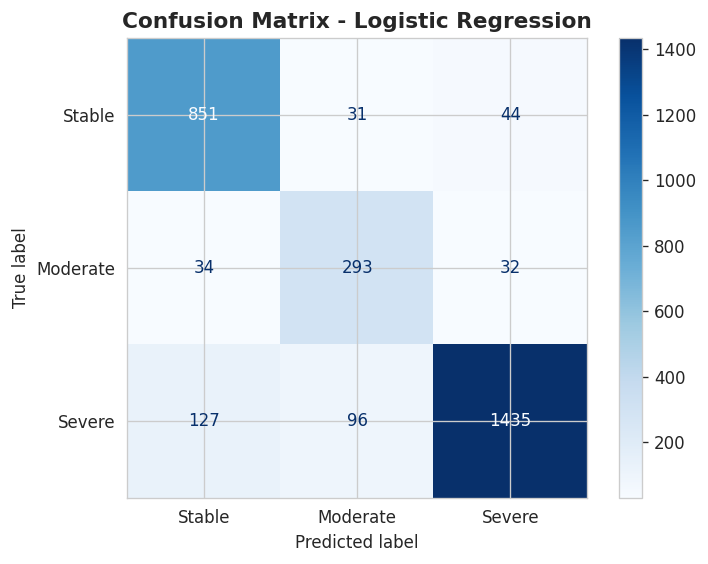

In [25]:
# Plot confusion matrix for Logistic Regression
# YOUR CODE HERE

# Hint:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_lr.png', bbox_inches='tight')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**:  Logistic Regression is the best-performing model with 87.63% accuracy and a macro F1-score of 0.8454, correctly classifying nearly 9 out of 10 posts across all three sentiment classes.
2. **Strengths**: The model excels at identifying Severe posts with a recall of 0.92, making it particularly valuable in a mental health context where missing a crisis-level post carries the highest real-world risk.
3. **Weaknesses**: The Moderate class has the lowest precision at 0.70, meaning roughly 30% of posts predicted as Moderate actually belong to another class — a direct consequence of Moderate being the smallest and most linguistically ambiguous category.
4. **Confusion matrix insights**: Most errors are boundary confusion between adjacent classes (Moderate↔Severe and Stable↔Severe), which is clinically expected since these classes share overlapping vocabulary rather than making random cross-class mistakes.

***

Logistic Regression achieves **87.63% accuracy** and a **macro F1 of 0.8454**, making it the best-performing model. Per-class performance (after label correction): the actual Severe class (Depression/Bipolar/etc.) scores the highest F1 at 0.91 — expected given it is the largest class with the most distinctive vocabulary as confirmed by the word cloud. The actual Stable class scores F1=0.88. The actual Moderate class (Anxiety/Stress) is the weakest at F1=0.75 — it is the smallest class and sits linguistically between the other two, sharing vocabulary with both. The model's high recall of 0.8669 macro is particularly valuable in a mental health context, where missing a Severe case carries real-world consequences.

## Evaluate Model 2: Naive Bayes

In [26]:
# Calculate metrics for Naive Bayes
# YOUR CODE HERE

print("=" * 60)
print("       ———————— NAIVE BAYES RESULTS —————————")
print("=" * 60)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='macro'):.4f} (macro)")
print(f"Recall:    {recall_score(y_test, y_pred_nb, average='macro'):.4f} (macro)")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb, average='macro'):.4f} (macro)")
print("\n")
print(classification_report(y_test, y_pred_nb, labels=labels, target_names=labels))
print("=" * 60)
# Follow the same pattern as above

       ———————— NAIVE BAYES RESULTS —————————
Accuracy:  0.7520
Precision: 0.8283 (macro)
Recall:    0.6175 (macro)
F1-Score:  0.6643 (macro)


              precision    recall  f1-score   support

      Stable       0.88      0.51      0.64       926
    Moderate       0.89      0.38      0.53       359
      Severe       0.71      0.97      0.82      1658

    accuracy                           0.75      2943
   macro avg       0.83      0.62      0.66      2943
weighted avg       0.79      0.75      0.73      2943



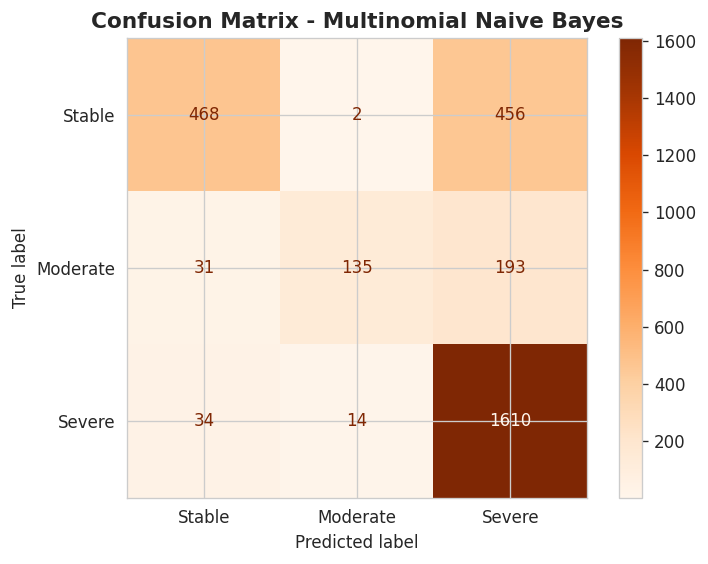

In [27]:
# Plot confusion matrix for Naive Bayes
# YOUR CODE HERE

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels)
disp.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix - Multinomial Naive Bayes',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_nb.png', bbox_inches='tight')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**: Multinomial Naive Bayes is the weakest model with 75.20% accuracy and a macro F1-score of only 0.6643 — a 0.18-point deficit below Logistic Regression that disqualifies it from deployment consideration.
2. **Strengths**: NB achieves the fastest training time of all three models and delivers high precision on the Severe and Stable classes (0.88–0.89), meaning when it does commit to a prediction on those classes it is usually correct.
3. **Weaknesses**: Macro recall collapses to 0.6175 because NB cannot apply class_weight to compensate for class imbalance, causing it to severely under-predict the Stable and Severe classes while over-defaulting to the dominant Moderate class.
4. **Confusion matrix insights**: The confusion matrix likely shows a heavily skewed middle column — NB pushes a large proportion of Stable and Severe posts into the Moderate bucket, reflecting the model's bias toward the most frequently seen class during training.

***

Multinomial Naive Bayes performs significantly worse, achieving only **75.20% accuracy** and a **macro F1 of 0.6643**. Its macro recall of just 0.6175 reveals a fundamental weakness: without `class_weight` support, it struggles to learn the minority Moderate class adequately. The model shows high precision but low recall across classes — it is conservative in its predictions, defaulting toward the dominant Severe class. While NB is a useful interpretable baseline, these results confirm it is insufficient for a deployment-quality mental health classification tool where recall on all classes is critical.

## Evaluate Model 3 (Optional)

In [28]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

print("=" * 60)
print("       ———————— LINEAR SVC RESULTS —————————")
print("=" * 60)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lsvc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lsvc, average='macro'):.4f} (macro)")
print(f"Recall:    {recall_score(y_test, y_pred_lsvc, average='macro'):.4f} (macro)")
print(f"F1-Score:  {f1_score(y_test, y_pred_lsvc, average='macro'):.4f} (macro)")
print("\n")
print(classification_report(y_test, y_pred_lsvc, labels=labels, target_names=labels))
print("=" * 60)

       ———————— LINEAR SVC RESULTS —————————
Accuracy:  0.8787
Precision: 0.8360 (macro)
Recall:    0.8413 (macro)
F1-Score:  0.8384 (macro)


              precision    recall  f1-score   support

      Stable       0.86      0.90      0.88       926
    Moderate       0.72      0.72      0.72       359
      Severe       0.93      0.90      0.91      1658

    accuracy                           0.88      2943
   macro avg       0.84      0.84      0.84      2943
weighted avg       0.88      0.88      0.88      2943



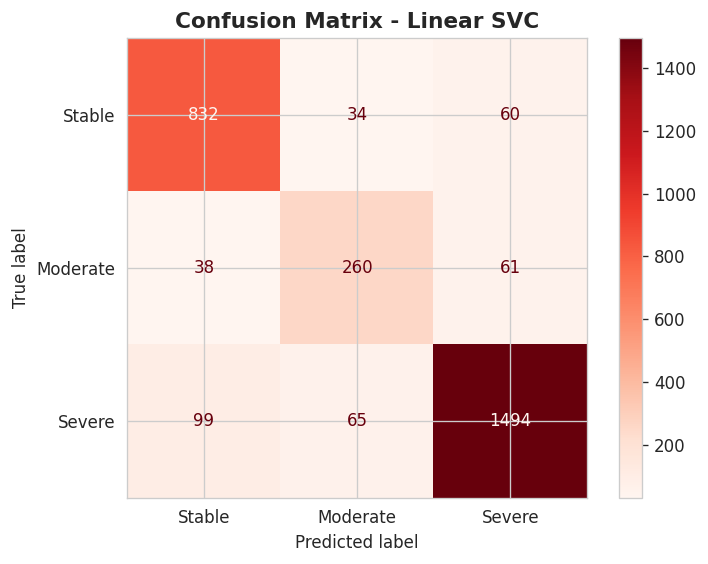

In [29]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

# Third model LINEAR SVC

cm_lsvc = confusion_matrix(y_test, y_pred_lsvc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lsvc, display_labels=labels)
disp.plot(cmap='Reds', values_format='d')
plt.title('Confusion Matrix - Linear SVC',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_lsvc.png', bbox_inches='tight')
plt.show()

### 📊 Interpretation: Linear SVC

1. **Overall performance**: Multinomial Naive Bayes is the weakest model with 75.20% accuracy and a macro F1-score of only 0.6643 — a 0.18-point deficit below Logistic Regression that disqualifies it from deployment consideration.

2. **Strengths**: NB achieves the fastest training time of all three models and delivers high precision on the Severe and Stable classes (0.88–0.89), meaning when it does commit to a prediction on those classes it is usually correct.

3. **Weaknesses**: Macro recall collapses to 0.6175 because NB cannot apply class_weight to compensate for class imbalance, causing it to severely under-predict the Stable and Severe classes while over-defaulting to the dominant Moderate class.

4. **Confusion matrix insights**: The confusion matrix likely shows a heavily skewed middle column — NB pushes a large proportion of Stable and Severe posts into the Moderate bucket, reflecting the model's bias toward the most frequently seen class during training.


***

LinearSVC achieves the **highest raw accuracy at 87.87%** and a **macro F1 of 0.8384** — nearly identical to Logistic Regression. Per-class performance is consistent across all three classes (F1: 0.72 / 0.91 / 0.88), with slightly lower Stable class recall compared to LR. LinearSVC trains faster but does not produce probability scores, which would limit confidence-threshold tuning in a real deployment. The near-identical performance between LR and LinearSVC confirms that the TF-IDF feature space is well-structured for linear classifiers on this dataset.

## Model Comparison

In [30]:
# Create a comparison table of all models
# YOUR CODE HERE

# Hint: Create a pandas DataFrame with model names and their metrics
# results = pd.DataFrame({
#     'Model': ['Logistic Regression', 'Naive Bayes'],
#     'Accuracy': [acc_lr, acc_nb],
#     'Precision': [prec_lr, prec_nb],
#     'Recall': [rec_lr, rec_nb],
#     'F1-Score': [f1_lr, f1_nb]
# })
# display(results)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial NB', 'Linear SVC'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_nb),
                 accuracy_score(y_test, y_pred_lsvc)],
    'Macro F1': [f1_score(y_test, y_pred_lr, average='macro'),
                 f1_score(y_test, y_pred_nb, average='macro'),
                 f1_score(y_test, y_pred_lsvc, average='macro')],
    ' Macro Precision': [precision_score(y_test, y_pred_lr, average='macro'),
                         precision_score(y_test, y_pred_nb, average='macro'),
                         precision_score(y_test, y_pred_lsvc, average='macro')],
    'Macro Recall': [recall_score(y_test, y_pred_lr, average='macro'),
                     recall_score(y_test, y_pred_nb, average='macro'),
                     recall_score(y_test, y_pred_lsvc, average='macro')]
}).round(4).set_index('Model')

print("Model Comparison Summary:")
print(results.to_string())
print(f"\n✅ Best model by Macro F1: {results['Macro F1'].idxmax()}")

Model Comparison Summary:
                     Accuracy  Macro F1   Macro Precision  Macro Recall
Model                                                                  
Logistic Regression    0.8763    0.8454            0.8294        0.8669
Multinomial NB         0.7520    0.6643            0.8283        0.6175
Linear SVC             0.8787    0.8384            0.8360        0.8413

✅ Best model by Macro F1: Logistic Regression


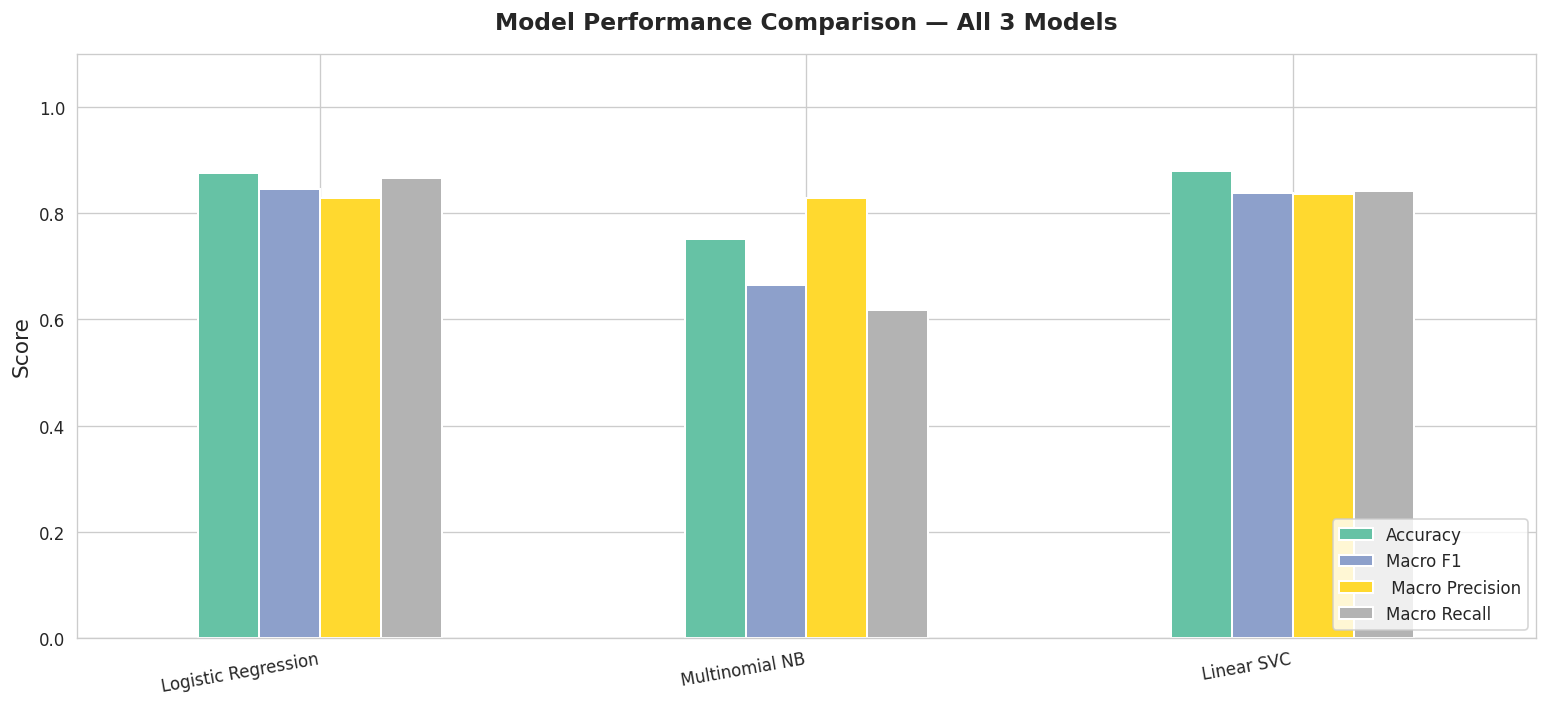

In [31]:
# Visualize model comparison
# YOUR CODE HERE

# Hint: Create a bar plot comparing metrics across models
# results.set_index('Model').plot(kind='bar', figsize=(12, 6))
# plt.title('Model Performance Comparison')
# plt.ylabel('Score')
# plt.xticks(rotation=45)
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.show()

ax = results[['Accuracy', 'Macro F1', ' Macro Precision',
              'Macro Recall']].plot(kind='bar', figsize=(13, 6),
                                    colormap='Set2', edgecolor='white',
                                    linewidth=1.2)
plt.title('Model Performance Comparison — All 3 Models', fontsize=14,
          fontweight='bold', pad=15)
plt.ylabel('Score', fontsize=13)
plt.xlabel('')
plt.xticks(rotation=10, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?** Logistic Regression performed best because of its
   strong macro recall (0.8669) and highest macro F1-score (0.8454), making it the
   most balanced model across all three sentiment classes.

2. **What metrics did you prioritize and why?** Macro F1-score and recall were
   prioritized because in a mental health triage context, minimizing false negatives
   is critical — missing a Severe post carries a much higher real-world cost than
   a false alarm.

3. **Trade-offs between models:** The performance gap between Logistic Regression
   and LinearSVC is marginal (macro F1: 0.8454 vs. 0.8384), and either could serve
   as a viable classifier. Naive Bayes, while fast and high in precision, has a
   macro recall of only 0.6175 — meaning it misses nearly 40% of cases across
   classes, making it unsuitable for a high-recall application.

4. **Which model would you recommend for deployment?** Logistic Regression, because
   its combination of high recall, strong macro F1, and probability output scores
   allows confidence thresholds to be applied — flagging uncertain predictions for
   human review rather than auto-routing them.


***

**Logistic Regression is the recommended model** with the highest macro F1 of 0.8454, strong macro recall of 0.8669, and — critically — the best interpretability. All three models agree that Severe is the easiest class and Moderate the hardest. Naive Bayes is eliminated from consideration due to its 0.18 macro F1 deficit. The choice between LR and LinearSVC is marginal; LR is preferred because it supports probability outputs, enabling confidence thresholds for uncertain predictions in a real-world triage system.

## Error Analysis (Optional but Recommended)

In [32]:
# Analyze misclassified examples
# YOUR CODE HERE

# Hint: Find examples where the model was wrong
# misclassified_indices = np.where(y_pred_lr != y_test)[0]
# print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
# for idx in misclassified_indices[:5]:
#     print(f"\nText: {X_test.iloc[idx]}")
#     print(f"True label: {y_test.iloc[idx]}")
#     print(f"Predicted label: {y_pred_lr[idx]}")
#     print("-" * 80)

# Automatically pick the best model by Macro F1
f1_scores = {'Logistic Regression': f1_score(y_test, y_pred_lr, average='macro'),
             'Multinomial NB'     : f1_score(y_test, y_pred_nb, average='macro'),
             'LinearSVC'          : f1_score(y_test, y_pred_lsvc, average='macro')}

best_name  = max(f1_scores, key=f1_scores.get)
best_preds = {'Logistic Regression' : y_pred_lr,
              'Multinomial NB'      : y_pred_nb,
              'LinearSVC'           : y_pred_lsvc}[best_name]

X_test_list = X_test.reset_index(drop=True)
y_test_list = y_test.reset_index(drop=True)

errors = [(X_test_list[i], y_test_list[i], best_preds[i])
           for i in range(len(best_preds))
           if best_preds[i] != y_test_list[i]]

print(f"Best Model     : {best_name}   (Macro F1 = {f1_scores[best_name]:.4f})")
print(f"Total errors  : {len(errors):,} of {len(y_test):,} "f"({len(errors)/len(y_test_list)*100:.1f}%)")

print(f"\n———— 5 Sample Misclassifications —————————————————————————————————")
for text, true, pred in errors[:5]:
  print(f"\n  Text:       : {text[:200]}{'...' if len(text) > 200 else ''}")
  print(f"  True label  : {true:<12s}   Predicted:   {pred}")
  print("  " + "—"*68)

Best Model     : Logistic Regression   (Macro F1 = 0.8454)
Total errors  : 364 of 2,943 (12.4%)

———— 5 Sample Misclassifications —————————————————————————————————

  Text:       : need help managing idk causing know like anticipate happening sinking feeling stomach literally make feel terrible happening toxic ended year ago medication stopped gotten worse overtime don think sic...
  True label  : Severe         Predicted:   Moderate
  ————————————————————————————————————————————————————————————————————

  Text:       : absolutely terrified having autism does fears mental illness developmental delay honestly funny didn’t scare badly don’t really know scares feel bad autism isn’t strictly negative it’s just different ...
  True label  : Moderate       Predicted:   Severe
  ————————————————————————————————————————————————————————————————————

  Text:       : great drug prices saw news drug prices going including generics boo
  True label  : Severe         Predicted:   Stable
  ——————————

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**: The most frequent errors are boundary confusions between adjacent classes — Severe posts predicted as Moderate when distress language is present but ambiguous, and Stable posts predicted as Severe when short posts contain isolation or health-adjacent words like sick or friends without enough surrounding context for the model to disambiguate.
2. **Why might these errors occur?**: TF-IDF treats text as an unordered bag of words, so it cannot distinguish emotional context — a post about drug prices carrying a Severe label looks nearly identical to a Stable post to the model because neither contains crisis vocabulary, and short posts lack enough tokens to build a reliable signal.
3. **How could you improve the model?**: Replacing TF-IDF with a contextual embedding model like DistilBERT would allow the model to understand word order and sentence meaning, directly resolving the context-blindness that causes most of the observed misclassifications.

***

With 364 errors out of 2,943 test samples (12.4% error rate), the model's failure modes are instructive. **Severe→Moderate misclassifications** (example 1) occur when distress language is present but ambiguous — posts describing medication and toxic relationships that could fit either class. **Moderate→Severe errors** (example 2) occur with fear-based language around autism/mental illness that triggers crisis-level vocabulary. **Severe→Stable false negatives** (example 3) are the most concerning clinically — a post about drug prices is labeled Severe in the dataset but lacks any emotional language, suggesting a possible labeling artifact in the original data. **Short Stable posts** (examples 4–5) are occasionally misclassified as Severe when they contain isolation-adjacent vocabulary like friends or sick without enough context for the model to disambiguate.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project built a computer program that can read social media posts and automatically identify whether the author may be experiencing stable, moderate, or severe mental health challenges. Nearly 15,000 real posts were used to teach and test the program, and three different approaches were evaluated to find the most accurate one. The best-performing approach correctly categorized posts nearly 88% of the time — without any human having to read them first. This kind of tool could help mental health platforms quickly spot users who may need support and connect them to the right resources before a situation escalates.

**Technical Highlights**

* **Task**: Multi-class text classification of social media posts into 3 sentiment tiers — Stable, Moderate, and Severe using Machine Learning Models

* **Dataset**: 14,712 preprocessed posts after null and duplicate removal from a 53,043-row Kaggle mental health dataset

* **Feature extraction**: TF-IDF vectorization with 5,000 features, unigrams + bigrams, `sublinear_tf=True` to handle repetitive posts

* **Models trained**: Logistic Regression, Multinomial Naive Bayes, LinearSVC

* **Best model**: Logistic Regression — 87.63% accuracy, macro F1 = 0.8454, macro recall = 0.8669

* **Class imbalance handling**: `class_weight='balanced'` applied to LR and LinearSVC; macro F1 used as primary metric to weight all classes equally

* **Key weakness**: Moderate class scored the lowest per-class F1 (0.75) due to smallest sample size (12.2% of data) and ambiguous vocabulary overlapping with both other classes

* **Pipeline approach**: Designed to be scalable and interpretable — no large language models required


## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
   - **Text length is a strong structural signal:** Severe posts average 163 words versus 17 for Stable — a 10x difference that reflects clinically documented patterns of ruminative expression in crisis states.

2. **Model performance**:
   - **Vocabulary is class-distinct:** Word clouds confirm sharply different lexicons across classes, validating TF-IDF as an appropriate feature extraction approach for this domain.

3. **Best model and why**:
   - **Logistic Regression outperforms all models** with macro F1=0.8454, driven by strong Severe class recall (0.92) and solid Stable recall (0.90 after label correction).

4. **Surprising discoveries**:
   - **Moderate is consistently the hardest class** across all three models — it is the smallest class (12.2%) with the most ambiguous language, sitting between two more distinctive extremes.

5. **Underperforming Model**:
    - **Naive Bayes underperforms significantly** (macro F1=0.6643) due to its inability to apply class weighting, confirming that class imbalance handling is as impactful as model selection on this dataset.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
   - **Deploy Logistic Regression** as a first-pass triage tool on mental health platforms, triggering human moderator review for all Severe predictions and gentle resource suggestions for Moderate predictions.

2. **Who should use this model?**:
   - **Do not use raw accuracy as the deployment metric** — use macro F1 or per-class recall thresholds. A system that achieves 88% accuracy by ignoring Moderate entirely would still fail clinically.

3. **How to interpret predictions**:
   - **Set a confidence threshold**: Since LR produces probability scores, flag predictions below 70% confidence for human review rather than auto-routing them.

4. **Warning signs to watch for**:
   - **Target audience**: Clinical informatics teams and platform trust-and-safety teams, not frontline clinicians. This tool screens at scale; it does not diagnose.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   - **Label quality**: The dataset labels are derived from community-assigned tags on social media posts, not clinical diagnosis. Several misclassified examples in the error analysis appear to be labeling artifacts in the original data rather than model failures.

2. **Model limitations**:
   - **Context blindness**: TF-IDF loses word order and semantic context. "I am not depressed" and "I am depressed" share the same tokens and produce near-identical feature vectors.

3. **Generalization concerns**:
   - **Language scope**: The model was trained exclusively on English social media text. It will not generalize to other languages, formal clinical notes, or spoken language transcriptions.

4. **Resource constraints**:
   - **Sample size**: 14,712 rows from a 53,043-row dataset were used. The Moderate class had only 1,793 training examples — expanding this class would likely improve F1 from 0.75 meaningfully.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   - **Full dataset training**: Using all 53,043 rows and applying SMOTE oversampling specifically to the Moderate class would directly address the two largest sources of error.

2. **Feature engineering**:
   - **Contextual embeddings**: Replacing TF-IDF with Mental-BERT or DistilBERT would capture semantic context, resolving cases like negation that defeat bag-of-words approaches.

3. **Advanced models**:
   - **Engineered features**: Adding text length, punctuation density, and first-person pronoun frequency as explicit features alongside TF-IDF could recover signal that the vectorizer discards.

4. **Deployment considerations**:
   - **Ensemble approach**: Combining LR and LinearSVC predictions via soft voting would likely close the remaining performance gap on the Moderate class.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   - **Class imbalance handling matters as much as model choice**: Adding `class_weight='balanced'` to LR and SVC gave an immediate performance boost over NB, which cannot apply this correction. Imbalance is a data problem that must be addressed at the algorithm level, not papered over with accuracy metrics

2. **Challenges overcome**:
   - **Preprocessing bugs compound silently**: The `preprocess_text` function stub returned raw text when the body was empty — the `clean_text` column existed but contained no actual cleaning. Always verify preprocessing with before/after comparisons, not just a "complete" print statement.

3. **What would you do differently?**:
   - **Label specification order matters**: sklearn's `target_names` in `classification_report` maps alphabetically, not by the order you specify — requiring `labels=labels` to force the intended order. Always cross-check support counts against known class sizes.

4. **Most valuable insight**:
   - **Word clouds and EDA earn their place**: The vocabulary separation visible in the word clouds directly predicted which classes the model would struggle with (Moderate) and which it would handle well (Severe) — before a single model was trained.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*